In [1]:
import torch
import torchaudio
import numpy as np
from pathlib import Path
from tqdm import tqdm
import os
import torchaudio
import io
import json
import re

current_directory = os.getcwd()
print("当前工作目录:", current_directory)

new_directory = '/mnt/workspace/'
os.chdir(new_directory)

current_directory = os.getcwd()
print("当前工作目录:", current_directory)

当前工作目录: /mnt/workspace/oss/yyj_ai/fake_reviews_detection
当前工作目录: /mnt/workspace


In [ ]:
if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    print(f'可用的 GPU 数量: {gpu_count}')
    for i in range(gpu_count):
        print(f'GPU {i}: {torch.cuda.get_device_name(i)}')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

# 一、基础设置

## （一）导入库

In [1]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
from torch import nn, optim
from tqdm import tqdm
import pickle

## （二）导入函数

In [2]:
from simple_tokenizer import SimpleTokenizer
from multimodal_model_new import ECommerceMultimodalModel  # 你的模型类
# from clip import preprocess_image  # 如果你自己封装了clip预处理，但我没有。

/opt/conda/envs/py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## （三）基础配置

In [3]:
# device = "cuda" if torch.cuda.is_available() else "cpu"
device="cpu"
BATCH_SIZE = 16
EPOCHS = 20
# LR = 1e-4

# 二、数据准备

## （一）导入地址和函数

In [4]:
# 加载clip
import clip
from PIL import Image

clip_model, preprocess = clip.load("ViT-B/32", device=device)
clip_model.eval()  # CLIP 一般冻结

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [6]:
train_path = "/mnt/workspace/oss/yyj_ai/fake_reviews_detection/tmp/train.pkl"
val_path = "/mnt/workspace/oss/yyj_ai/fake_reviews_detection/tmp/val.pkl"
test_path = "/mnt/workspace/oss/yyj_ai/fake_reviews_detection/tmp/test.pkl"
MODEL_SAVE_PATH = "/mnt/workspace/oss/yyj_ai/fake_reviews_detection/tmp/multimodal_model_final.pt"

In [7]:
import pandas as pd

train_df = pd.read_pickle(train_path)
val_df   = pd.read_pickle(val_path)
test_df  = pd.read_pickle(test_path)

In [8]:
from transformers import BertTokenizer  # 不是 BertModel

# 1. 加载分词器
bert_tokenizer = BertTokenizer.from_pretrained("/mnt/workspace/oss/yyj_ai/fake_reviews_detection/model/")

class ReviewDataset(Dataset):
    def __init__(self, df, preprocess):
        self.df = df.reset_index(drop=True)
        self.preprocess = preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row["text_clean"]

        # 2. 用分词器编码文本
        bert_enc = bert_tokenizer(
            text,
            max_length=77,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        bert_input_ids = bert_enc["input_ids"].squeeze(0)        # [77]
        bert_attention_mask = bert_enc["attention_mask"].squeeze(0)

        # CLIP 部分保持不变
        clip_input_ids = clip.tokenize([text], truncate=True).squeeze(0)

        image = Image.open(row["img_local_path"]).convert("RGB")
        image_tensor = self.preprocess(image)

        return {
            "bert_input_ids": bert_input_ids,
            "bert_attention_mask": bert_attention_mask,
            "clip_input_ids": clip_input_ids,
            "image_tensor": image_tensor,
            "label": torch.tensor(row["label"], dtype=torch.long)
        }

## （二）加载数据

In [9]:
train_dataset = ReviewDataset(train_df, preprocess)
val_dataset   = ReviewDataset(val_df, preprocess)
test_dataset  = ReviewDataset(test_df, preprocess)

# 数据迭代器dataloader
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [10]:
# 测试自检一下

batch = next(iter(train_loader))
for k, v in batch.items():
    print(k, v.shape, v.dtype)


/opt/conda/envs/py3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


bert_input_ids torch.Size([16, 77]) torch.int64
bert_attention_mask torch.Size([16, 77]) torch.int64
clip_input_ids torch.Size([16, 77]) torch.int32
image_tensor torch.Size([16, 3, 224, 224]) torch.float32
label torch.Size([16]) torch.int64


# 三、模型准备

## （一）导入地址

In [11]:
from transformers import BertModel, BertTokenizer

# local_model_path = "/mnt/workspace/oss/yyj_ai/fake_reviews_detection/model/bert-base-chinese/"

# tokenizer = BertTokenizer.from_pretrained(local_model_path)
# model = BertModel.from_pretrained(local_model_path)

bert = BertModel.from_pretrained("/mnt/workspace/oss/yyj_ai/fake_reviews_detection/model/bert-base-chinese/")

## （二）初始化模型

In [12]:
from multimodal_model_new import ECommerceMultimodalModel
import torch
import torch.nn as nn
from torch.optim import AdamW                 # ← 补上
from torch.optim.lr_scheduler import CosineAnnealingLR   # ← 补上

device = "cpu"
LR = 1e-4

model = ECommerceMultimodalModel(bert_model=bert).to(device)

# 优化点：引入 Label Smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# 优化点：使用 AdamW 并设置 weight_decay
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.05)

# 优化点：T_max 设置为 总迭代步数 (epochs * len(dataloader))
total_steps = EPOCHS * len(train_loader)
scheduler = CosineAnnealingLR(optimizer, T_max=total_steps, eta_min=1e-7)

/opt/conda/envs/py3.11/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/py3.11/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## （三）定义训练和评估函数

In [13]:
def train_one_epoch(model, dataloader, optimizer, criterion, scheduler, device):
    model.train()
    running_loss = 0.0

    for batch in tqdm(dataloader, desc="Training"):
        optimizer.zero_grad()

        # 统一字段名
        bert_input_ids   = batch["bert_input_ids"].to(device)
        bert_attn_mask   = batch["bert_attention_mask"].to(device)
        clip_input_ids   = batch["clip_input_ids"].to(device)
        image_tensor     = batch["image_tensor"].to(device)
        labels           = batch["label"].to(device)

        logits = model(bert_input_ids, bert_attn_mask,
                       clip_input_ids, image_tensor)
        loss = criterion(logits, labels)

        # loss.backward()
        # optimizer.step()
        # running_loss += loss.item()

        loss.backward()
        # 梯度裁剪：防止 Transformer 结构梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()  # 优化点：每个 Step 更新学习率，更平滑

        running_loss += loss.item()

    return running_loss / len(dataloader)

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_true, all_pred = [], []

    for batch in tqdm(dataloader, desc="Evaluating"):
        bert_input_ids = batch["bert_input_ids"].to(device)
        bert_attn_mask = batch["bert_attention_mask"].to(device)
        clip_input_ids = batch["clip_input_ids"].to(device)
        image_tensor   = batch["image_tensor"].to(device)
        labels = batch["label"].to(device)

        logits = model(bert_input_ids, bert_attn_mask,
                       clip_input_ids, image_tensor)
        loss = criterion(logits, labels)
        total_loss += loss.item()

        preds = logits.argmax(dim=1)
        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(all_true, all_pred)
    return total_loss/len(dataloader), acc, all_true, all_pred

# 四、训练模型

## （一）模型训练

In [ ]:
# 如果想快速看loss

# from torch.utils.data import Subset, DataLoader
# import numpy as np

# def build_train_monitor_loader(train_dataset, monitor_size=2048, batch_size=256):
#     """随机抽 monitor_size 条样本，专门用来算 train_acc"""
#     indices = np.random.choice(len(train_dataset), size=monitor_size, replace=False)
#     subset = Subset(train_dataset, indices)
#     # 用更大 batch 加速 forward
#     return DataLoader(subset, batch_size=batch_size*2, shuffle=False,
#                       num_workers=4, pin_memory=True)


# history = {'train_loss': [], 'train_acc': [],
#            'val_loss': [], 'val_acc': [],
#            'val_pre_0': [], 'val_rec_0': [], 'val_f1_0': [],
#            'val_pre_1': [], 'val_rec_1': [], 'val_f1_1': []}

# best_val_acc = 0
# MONITOR_FREQ = 3          # 每 3 个 epoch 算一次 train_acc
# train_monitor_loader = build_train_monitor_loader(train_dataset)

# for epoch in range(1, EPOCHS+1):
#     print(f'\nEpoch {epoch}/{EPOCHS}')
#     # ---------- 训练 ----------
#     train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

#     # ---------- 监控用 train_acc（低频 + 子集） ----------
#     if epoch % MONITOR_FREQ == 0:
#         _, train_acc, _, _ = evaluate(model, train_monitor_loader, criterion, device)
#     else:
#         train_acc = np.nan          # 本轮跳过
#     history['train_loss'].append(train_loss)
#     history['train_acc'].append(train_acc)

#     # ---------- 验证 ----------
#     val_loss, val_acc, val_true, val_pred = evaluate(model, val_loader, criterion, device)
#     report = classification_report(val_true, val_pred,
#                                    target_names=['real(0)', 'fake(1)'],
#                                    output_dict=True, zero_division=0)
#     history['val_loss'].append(val_loss)
#     history['val_acc'].append(val_acc)
#     for cls in ['real(0)', 'fake(1)']:
#         idx = 0 if cls == 'real(0)' else 1
#         history[f'val_pre_{idx}'].append(report[cls]['precision'])
#         history[f'val_rec_{idx}'].append(report[cls]['recall'])
#         history[f'val_f1_{idx}'].append(report[cls]['f1-score'])

#     print(f'Train Loss: {train_loss:.4f} | '
#           f'Train Acc: {train_acc:.4f} | ' if not np.isnan(train_acc) else '',
#           f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

#     scheduler.step()

#     # 存最优
#     if val_acc > best_val_acc:
#         best_val_acc = val_acc
#         torch.save(model.state_dict(), MODEL_SAVE_PATH)
#         print('Best model saved!')

In [16]:
history = {'train_loss': [], 'train_acc': [],
           'val_loss': [], 'val_acc': [],
           'val_pre_0': [], 'val_rec_0': [], 'val_f1_0': [],
           'val_pre_1': [], 'val_rec_1': [], 'val_f1_1': []}

best_val_acc = 0
for epoch in range(1, EPOCHS+1):
    print(f'\nEpoch {epoch}/{EPOCHS}')
    # ---------- 训练 ----------
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, device)
    # 再算一次训练集准确率（小数据可接受，大数据就用随机子集）
    _, train_acc, _, _ = evaluate(model, train_loader, criterion, device) # 仅作监控
    # ---------- 验证 ----------
    val_loss, val_acc, val_true, val_pred = evaluate(model, val_loader, criterion, device)

    # 每类的 P/R/F1
    report = classification_report(val_true, val_pred,
                                   target_names=['real(0)', 'fake(1)'],
                                   output_dict=True, zero_division=0)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    # 分别记录 real(0) 与 fake(1)
    for cls in ['real(0)', 'fake(1)']:
        idx = 0 if cls == 'real(0)' else 1
        history[f'val_pre_{idx}'].append(report[cls]['precision'])
        history[f'val_rec_{idx}'].append(report[cls]['recall'])
        history[f'val_f1_{idx}'].append(report[cls]['f1-score'])

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    scheduler.step()

    # 存最优
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print('Best model saved!')


Epoch 1/20


Training:   0%|          | 0/341 [00:00<?, ?it/s]/opt/conda/envs/py3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   0%|          | 1/341 [00:02<13:54,  2.46s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   6%|▌         | 19/341 [00:30<08:20,  1.55s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:  12%|█▏        | 40/341 [01:

Train Loss: 0.5377 | Train Acc: 0.8571 | Val Loss: 0.4252 | Val Acc: 0.8579
Best model saved!

Epoch 2/20


Training:   0%|          | 0/341 [00:00<?, ?it/s]/opt/conda/envs/py3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Training:   0%|          | 1/341 [00:02<13:41,  2.42s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   2%|▏         | 6/341 [00:10<08:51,  1.59s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   3%|▎         | 11/341 [00:17<08:33,  1.56s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA image

Train Loss: 0.4390 | Train Acc: 0.8874 | Val Loss: 0.3844 | Val Acc: 0.8861
Best model saved!

Epoch 3/20


...

Train Loss: 0.2798 | Train Acc: 0.9639 | Val Loss: 0.3477 | Val Acc: 0.9144

Epoch 19/20


Training:   0%|          | 0/341 [00:00<?, ?it/s]/opt/conda/envs/py3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Training:   1%|          | 2/341 [00:04<11:03,  1.96s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   3%|▎         | 11/341 [00:18<08:47,  1.60s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   5%|▍         | 17/341 [00:27<08:34,  1.59s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA imag

Train Loss: 0.2816 | Train Acc: 0.9630 | Val Loss: 0.3473 | Val Acc: 0.9161

Epoch 20/20


Training:   0%|          | 0/341 [00:00<?, ?it/s]/opt/conda/envs/py3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   2%|▏         | 7/341 [00:11<09:01,  1.62s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Training:   4%|▎         | 12/341 [00:19<08:48,  1.61s/it]/opt/conda/envs/py3.11/lib/python3.11/

Train Loss: 0.2792 | Train Acc: 0.9630 | Val Loss: 0.3477 | Val Acc: 0.9135


## （二）模型评估

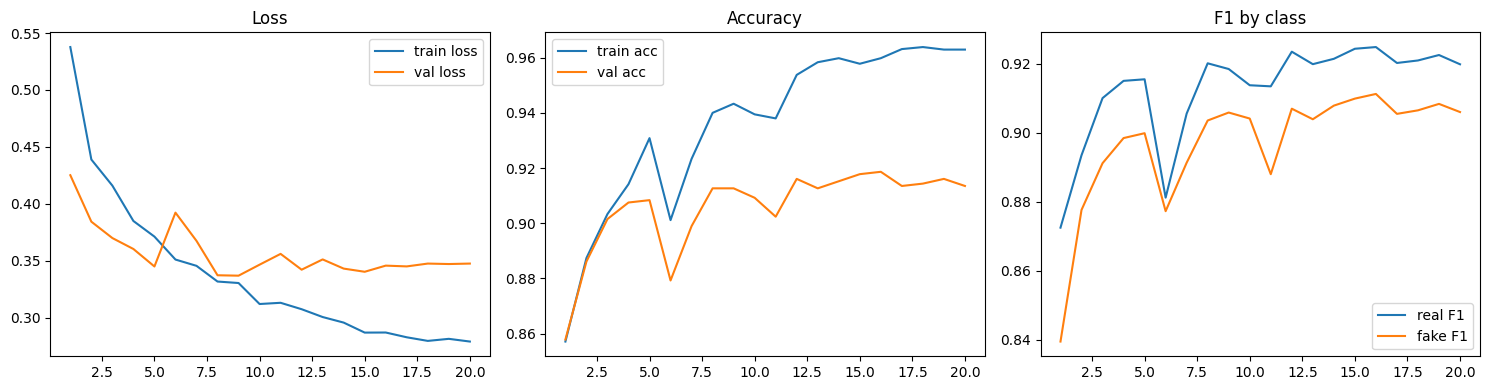

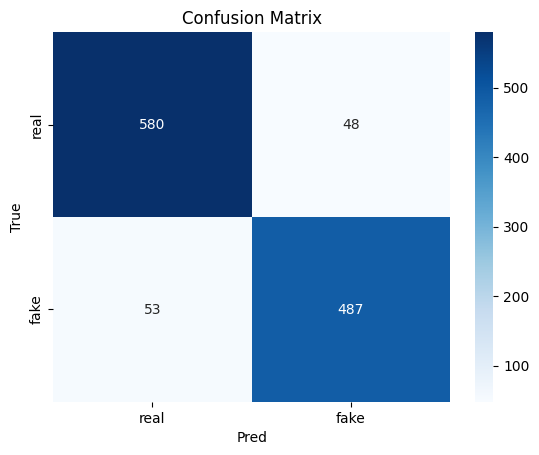

In [23]:
def plot_training(history):
    epochs = range(1, len(history['train_loss'])+1)
    plt.figure(figsize=(15,4))

    # ---- loss / acc 曲线 ----
    plt.subplot(1,3,1)
    plt.plot(epochs, history['train_loss'], label='train loss')
    plt.plot(epochs, history['val_loss'], label='val loss')
    plt.title('Loss'); plt.legend(); plt.grid(False)

    plt.subplot(1,3,2)
    plt.plot(epochs, history['train_acc'], label='train acc')
    plt.plot(epochs, history['val_acc'], label='val acc')
    plt.title('Accuracy'); plt.legend(); plt.grid(False)

    # ---- 每类 F1 ----
    plt.subplot(1,3,3)
    plt.plot(epochs, history['val_f1_0'], label='real F1')
    plt.plot(epochs, history['val_f1_1'], label='fake F1')
    plt.title('F1 by class'); plt.legend(); plt.grid(False)

    plt.tight_layout(); plt.show()

    # ---- 混淆矩阵（最后一 epoch）----
    cm = confusion_matrix(val_true, val_pred)
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=['real','fake'],
                yticklabels=['real','fake'],
                cmap='Blues')
    plt.ylabel('True'); plt.xlabel('Pred'); plt.title('Confusion Matrix')
    plt.show()

# 训练完成后调用
plot_training(history)

In [31]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
out = evaluate(model, test_loader, criterion, device)
print(type(out),len(out))
print(out)

Evaluating:   0%|          | 0/74 [00:00<?, ?it/s]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:   5%|▌         | 4/74 [00:05<01:31,  1.31s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  14%|█▎        | 10/74 [00:13<01:20,  1.25s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 74/74 [01:26<00:00,  1.17s/it]

<class 'tuple'> 4
(0.36762671635763067, 0.9170230966638152, [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.

In [32]:
test_loss, test_acc, preds, labels = evaluate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

Evaluating:   0%|          | 0/74 [00:00<?, ?it/s]/opt/conda/envs/py3.11/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:   5%|▌         | 4/74 [00:05<01:30,  1.29s/it]/opt/conda/envs/py3.11/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  14%|█▎        | 10/74 [00:12<01:17,  1.22s/it]/opt/conda/envs/py3.11/lib/python3.

Test Loss: 0.3676 | Test Acc: 0.9170


In [34]:
from sklearn.metrics import classification_report, accuracy_score

print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(labels, preds, target_names=['real', 'fake']))

Test Loss: 0.3676 | Test Acc: 0.9170

Classification Report:
              precision    recall  f1-score   support

        real       0.93      0.91      0.92       644
        fake       0.90      0.92      0.91       525

    accuracy                           0.92      1169
   macro avg       0.92      0.92      0.92      1169
weighted avg       0.92      0.92      0.92      1169



In [35]:
from sklearn.metrics import classification_report, accuracy_score

# 1. 纯手写格式，完全控制小数位
print(f"Test Loss: {test_loss:.6f} | Test Acc: {accuracy_score(labels, preds):.6f}")

# 2. 把 classification_report 转成 DataFrame 再改精度
import pandas as pd
report = classification_report(
    labels, preds,
    target_names=['real', 'fake'],
    output_dict=True          # 返回 dict 而不是字符串
)
df = pd.DataFrame(report).T   # 转置后每一行是一个类别
print(df.round(6))            # 6 位小数，也可以改成 8、10 …

Test Loss: 0.367627 | Test Acc: 0.917023
              precision    recall  f1-score      support
real           0.934817  0.913043  0.923802   644.000000
fake           0.896296  0.921905  0.908920   525.000000
accuracy       0.917023  0.917023  0.917023     0.917023
macro avg      0.915557  0.917474  0.916361  1169.000000
weighted avg   0.917517  0.917023  0.917119  1169.000000


In [24]:
print(model)

ECommerceMultimodalModel(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequen

In [36]:
torch.save(model.state_dict(), 'best.pt')